In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("E:/NOUR/Documents/PFE/data/marketing.csv")


In [7]:
data.head() 


,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained
0,a100000029,1/1/18,House Ads,personalization,True,English,English,0-18 years,1/1/18,NaN,House Ads,True
1,a100000030,1/1/18,House Ads,personalization,True,English,English,19-24 years,1/1/18,NaN,House Ads,True
2,a100000031,1/1/18,House Ads,personalization,True,English,English,24-30 years,1/1/18,NaN,House Ads,True
3,a100000032,1/1/18,House Ads,personalization,True,English,English,30-36 years,1/1/18,NaN,House Ads,True
4,a100000033,1/1/18,House Ads,personalization,True,English,English,36-45 years,1/1/18,NaN,House Ads,True


In [5]:
data.isna().any()

user_id                False
date_served             True
marketing_channel       True
variant                False
converted               True
language_displayed     False
language_preferred     False
age_group              False
date_subscribed         True
date_canceled           True
subscribing_channel     True
is_retained             True
dtype: bool

In [6]:
data['is_retained'] = data['is_retained'].astype('bool')

In [8]:
print(data['is_retained'].dtype)

bool


In [9]:
data['is_correct_lang'] = np.where( data['language_preferred'] == data['language_displayed'],  'Yes', 'No')

In [10]:
data2 = pd.read_csv("E:/NOUR/Documents/PFE/data/marketing.csv",parse_dates=['date_served','date_subscribed','date_canceled'])

In [12]:
daily_users = data2.groupby(['date_served'])['user_id'].nunique()

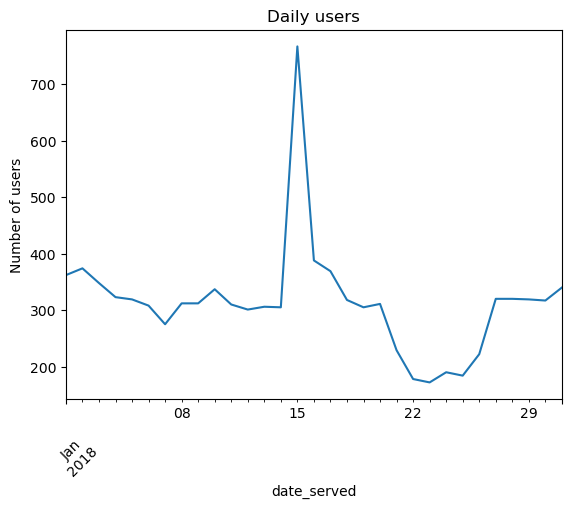

In [13]:
daily_users.plot()

# Include a title and y-axis label
plt.title('Daily users')
plt.ylabel('Number of users')

# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation = 45)

# Display the plot
plt.show()  

In [15]:
total =data2['user_id'].nunique()

In [16]:
subscribers = data2[data2["converted"] == True]\
                       ['user_id'].nunique()

# Calculate the conversion rate
conversion_rate = subscribers/total
print(round(conversion_rate*100, 2), "%")

13.89 %


In [17]:
total_subscribers = data[data["converted"] == True]\
                            ['user_id'].nunique()

# Calculate the number of people who remained subscribed
retained = data[data['is_retained'] == True]\
                   ['user_id'].nunique()

# Calculate the retention rate   
retention_rate = retained/total_subscribers
print(round(retention_rate*100, 2), "%") 

686.4 %


In [19]:
english_speaker = data2[data2['language_displayed'] == 'English']

In [20]:
total = english_speaker['user_id'].nunique()

In [21]:
subscribers = english_speaker[english_speaker['converted'] == True]\
['user_id'].nunique()

In [22]:
conversion_rate = subscribers/total
print('English speaker conversion rate:',  round(conversion_rate*100,2), '%')

English speaker conversion rate: 12.92 %


In [23]:
# Group by language_displayed and count unique users
total = data2.groupby('language_displayed')['user_id'].nunique()
        
# Group by language_displayed and count unique conversions
subscribers = data2[data2['converted'] == True]\
              .groupby(['language_displayed'])\
              ['user_id'].nunique()

# Calculate the conversion rate for all languages
language_conversion_rate = subscribers/total
print(language_conversion_rate)

language_displayed
Arabic     0.500000
English    0.129167
German     0.716216
Spanish    0.200000
Name: user_id, dtype: float64


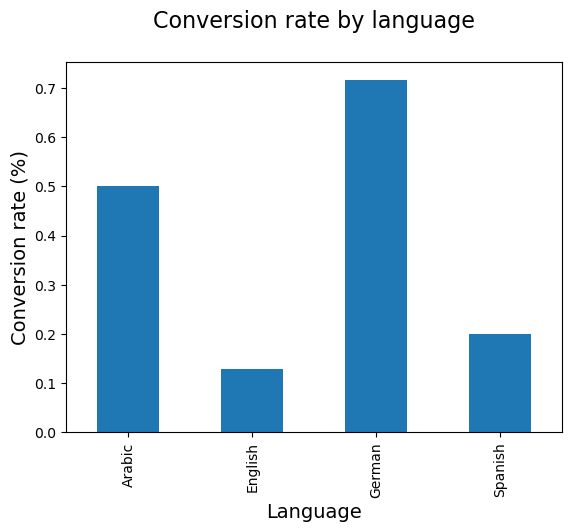

In [24]:
# Create a bar chart using language_conversion_rate DataFrame
language_conversion_rate.plot(kind ='bar')

# Add a title and x and y-axis labels
plt.title('Conversion rate by language\n', size = 16)
plt.xlabel('Language', size = 14)
plt.ylabel('Conversion rate (%)', size = 14)

# Display the plot
plt.show()

In [25]:
#Aggregating by date 

# Group by date_served and count unique users

total = data2.groupby('date_served')['user_id'].nunique()

# Group by date_served and count unique converted users
subscribers = data2[data2['converted']==True]\
              .groupby(['date_served'])\
              ['user_id'].nunique()

# Calculate the conversion rate per day
daily_conversion_rate = subscribers/total
print(daily_conversion_rate)

date_served
2018-01-01    0.099448
2018-01-02    0.098930
2018-01-03    0.103448
2018-01-04    0.108359
2018-01-05    0.125392
2018-01-06    0.113636
2018-01-07    0.141818
2018-01-08    0.115385
2018-01-09    0.125000
2018-01-10    0.118694
2018-01-11    0.080645
2018-01-12    0.076412
2018-01-13    0.084967
2018-01-14    0.085246
2018-01-15    0.113429
2018-01-16    0.255155
2018-01-17    0.219512
2018-01-18    0.091195
2018-01-19    0.059016
2018-01-20    0.067524
2018-01-21    0.087336
2018-01-22    0.123596
2018-01-23    0.122093
2018-01-24    0.115789
2018-01-25    0.125000
2018-01-26    0.090090
2018-01-27    0.065625
2018-01-28    0.062500
2018-01-29    0.059561
2018-01-30    0.066246
2018-01-31    0.052941
Name: user_id, dtype: float64


In [26]:
# Reset index to turn the results into a DataFrame
daily_conversion_rate = pd.DataFrame(daily_conversion_rate.reset_index(0))

In [27]:
daily_conversion_rate.columns  # now the dataframe

Index(['date_served', 'user_id'], dtype='object')

In [28]:
daily_conversion_rate.head()

,date_served,user_id
0,2018-01-01,0.099448
1,2018-01-02,0.098930
2,2018-01-03,0.103448
3,2018-01-04,0.108359
4,2018-01-05,0.125392


In [29]:
# Rename columns
daily_conversion_rate.columns = ['date_served','conversion_rate']  # userId now conversion rate 

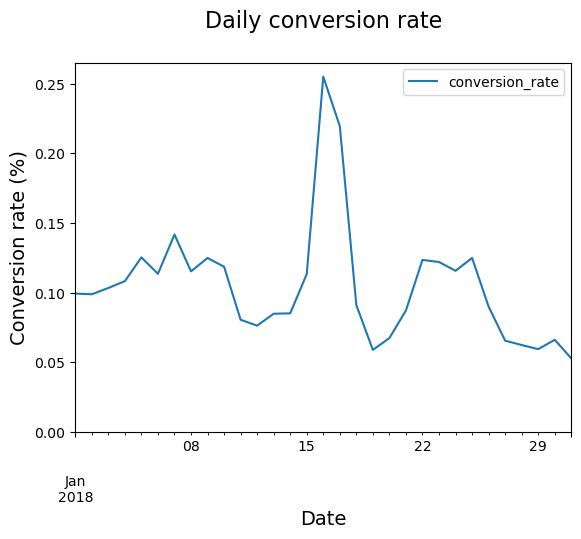

In [30]:
# Create a line chart using daily_conversion_rate
daily_conversion_rate.plot('date_served','conversion_rate')

plt.title('Daily conversion rate\n', size = 16)
plt.ylabel('Conversion rate (%)', size = 14)
plt.xlabel('Date', size = 14)

# Set the y-axis to begin at 0
plt.ylim(0)

# Display the plot  # there is seems to be one spike after 15 jan
plt.show()

In [32]:
# Group by date subscribed  and count unique users
total = data2.groupby(['date_subscribed'])['user_id']\
            .nunique()

# Group by date_scubscribed and who are retained after subscribtion

retained = data2[data2['is_retained'] == True]\
                .groupby(['date_subscribed'])\
                ['user_id'].nunique()
# Calculate subscriber quality across dates
daily_retention_rate = retained/total

In [33]:
# Reset index to turn the Series into a DataFrame
daily_retention_rate =pd.DataFrame(daily_retention_rate.reset_index())

In [34]:
# Rename columns
daily_retention_rate.columns = ['date_subscribed','retention_rate']

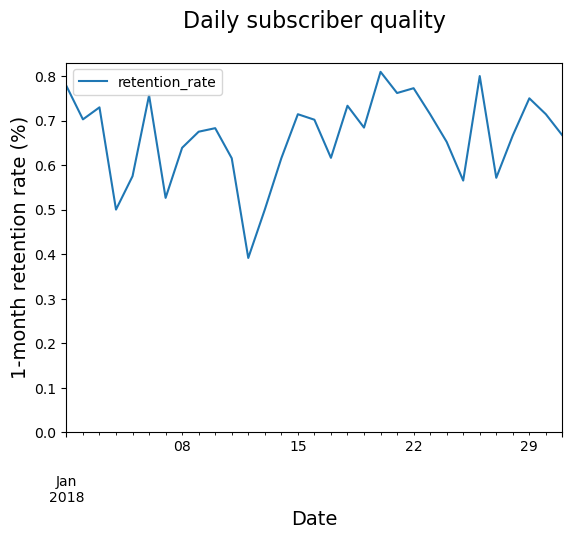

In [35]:
# Create a line chart using the daily_retention DataFrame

daily_retention_rate.plot('date_subscribed','retention_rate')

# Add a title and x and y-axis labels
plt.title('Daily subscriber quality\n', size = 16)
plt.ylabel('1-month retention rate (%)', size = 14)
plt.xlabel('Date', size = 14)
# Set the y-axis to begin at 0
plt.ylim(0)
# Display the plot
plt.show()

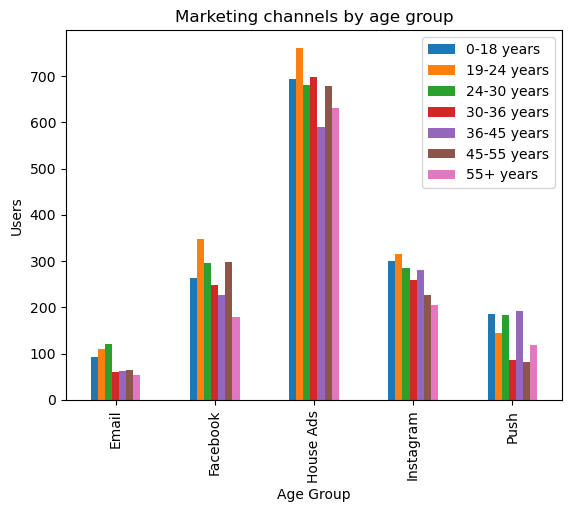

In [37]:
# Group by marketeing channel and age group per user Id

channel_age = data2.groupby(['marketing_channel', 'age_group'])\
                                ['user_id'].count()

# Unstack channel_age and transform it into a DataFrame #Unstacking after groupby

channel_age_df = pd.DataFrame(channel_age.unstack(level = 1)) # as index = 0

# Plot channel_age

channel_age_df.plot(kind = 'bar')
plt.title('Marketing channels by age group')
plt.xlabel('Age Group')
plt.ylabel('Users')
# Add a legend to the plot
plt.legend(loc = 'upper right', 
           labels = channel_age_df.columns.values)
plt.show()

In [38]:
channel_age_df.head() # can check the all marketing channels serving different age group 

age_group,0-18 years,19-24 years,24-30 years,30-36 years,36-45 years,45-55 years,55+ years
marketing_channel,,,,,,,
Email,93,111,120,60,63,65,53
Facebook,264,347,296,249,226,299,179
House Ads,694,761,681,699,589,678,631
Instagram,300,315,286,259,280,227,204
Push,186,145,183,86,193,82,118


In [39]:
# Count the subscription by subscribing channel and each day

#Use .groupby() to calculate subscribers by subscribing_channel and date_subscribed.

retention_total =data.groupby(['date_subscribed','subscribing_channel'] )['user_id'].nunique() 

# Print results
print(retention_total.head())

date_subscribed  subscribing_channel
1/1/18           Email                   1
                 Facebook                8
                 House Ads              16
                 Instagram               8
                 Push                    3
Name: user_id, dtype: int64


In [41]:
#Count the retained subs by subscribing channel and date subscribed

retention_subs = data2[data2['is_retained'] == True]\
                           .groupby(['date_subscribed',
                                     'subscribing_channel'])\
                            ['user_id'].nunique()

In [51]:
# Divide retained subscribers by total subscribers
retention_rate = retention_subs/retention_total

#unstack the retention rate and convert in to dataframe

retention_rate_df = pd.DataFrame(retention_rate.unstack(level=1))

C:\Users\NOUR\AppData\Local\Temp\ipykernel_8960\3295073032.py:2: RuntimeWarning: The values in the array are unorderable. Pass `sort=False` to suppress this warning.
  retention_rate = retention_subs/retention_total


In [52]:
c.isna().count()

subscribing_channel
Email        62
Facebook     62
House Ads    62
Instagram    62
Push         62
dtype: int64

In [49]:
retention_rate_df.dropna(inplace =True)

In [53]:
retention_rate_df.head()

subscribing_channel,Email,Facebook,House Ads,Instagram,Push
date_subscribed,,,,,
2018-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
2018-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN
2018-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN
2018-01-04 00:00:00,NaN,NaN,NaN,NaN,NaN
2018-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN
